# 流式执行

一些基础的python语言也会涉及到，streaming execution，就是程序没有结束，把中间结果（包含很多）

比如状态变化，执行中的事件，都可以输出出来，就叫流式执行

invoke不是流式执行，而是整个执行完之后，告诉你结果， 改成流执行会一遍执行超步，一遍产生事件，然后调用方法，然后把结果返回回来，  在实际生产大型Agent响应久，不能等半天

输出一些中间结果，体验更好

1. langgraph的流式执行，把节点输出，状态更新，消息增量，自定义事件或调试信息写到流式队列中，然后在特定时机返回给调用者，

所有stream_mode都有案例

流式执行分为同步和异步
1. 同步执行进入内部的同步流式队列
2. 异步执行，进入对应的异步队列

不管同步还是异步，调用方可以用迭代器方式消费队列里的数据，不需要等整个图执行完毕

流式执行和终点执行对应
同步与异步对应

流式执行既可以用同步，也可以用异步
这里讲流式执行， 可以获取中间结果

有两套方法，
1. stream和astream， astream是异步 （输出数据本身，有什么数据产生什么数据）
2. astream_events，流式执行里，每一个流程封装成了标准事件，（带有events的版本，输出封装好的结构化的东西， 叫做runnable事件，封装好事件，然后把事件打印出来）

# stream/astream
这里同步和异步的概念，和python里面一样，下面有表格对应关系


同步可以保证顺序确定的（一般用同步）
如果异步，用asyncio， 用异步迭代，理解起来，就是效率快一点，但是快慢不能保证， 前后顺序保重，前后不好说

这里主要讲同步， 异步代码差不多,这里演示同步

支持两种输出格式的数据，
1. v1版本的默认模式（版本使用较多）
stream_mode可选多个
| 模式 | 输出内容 | 适用场景 |
|:---|:---|:---|
| **`values`** | 每个超步后的完整状态 | 需要完整状态快照 |
| **`updates`** | 节点产生的状态更新（增量） | 只关心节点输出变化 |
| **`messages`** | `messages` 状态字段的增量更新 | LLM 对话流式输出 |
| **`checkpoints`** | 检查点更新事件（需检查点存储器） | 持久化监控、中断调试 |
| **`tasks`** | 任务开始/结果事件（含触发通道、异常） | 运行时观测、任务追踪 |
| **`debug`** | `checkpoints` + `tasks` 的统一封装，附加超步编号、时间戳 | 调试排错 |
| **`custom`** | 节点/工具通过 `stream_writer` 主动写出的自定义数据 | 进度通知、阶段说明 |


选一个是单个流模式，只有一种。  多个流模式， 会输出元祖，返回(mode, data)， 启用了子图，就会额外增加命名空间信息

v2基于v1封装成了StreamPart，就是旧的type,data,再补充上ns

下面展示下v1什么样子，最后再看下v2

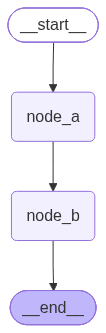

('values', {'initial_state': '初始状态'})
('values', {'initial_state': '初始状态', 'node_a_output': '节点A的输出'})
('values', {'initial_state': '初始状态', 'node_a_output': '节点A的输出', 'node_b_output': '节点B的输出'})


In [4]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
import  time
class OverAllState(TypedDict):
    initial_state: str
    node_a_output: str
    node_b_output: str

def node_a(state: OverAllState) -> OverAllState:
    time.sleep(2)
    return {
        "node_a_output": "节点A的输出"
    }

def node_b(state: OverAllState) -> OverAllState:
    time.sleep(2)
    return {
        "node_b_output": "节点B的输出"
    }

builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_edge(START, "node_a")
builder.add_edge("node_a", "node_b")
builder.add_edge("node_b", END)

graph = builder.compile()

display(graph)

# 要使用流式执行 .stream .astream
# 流式执行就是在图运行的过程当中把中间结果打印出来
for chunk in graph.stream(   # 入参注意
    {"initial_state": "初始状态"},
    stream_mode=["values"],
):
    print(chunk) # 如果invoke只有最后一条，如果是了；流式执行，中间的也会打印出来

In [ ]:

for chunk in graph.stream(   # 入参呵呵
    {"initial_state": "初始状态"},
    stream_mode=["updates"], # 只显示增量的内容， 没有显示所有的内容
    version="v2"
):
    print(chunk)

{'type': 'updates', 'ns': (), 'data': {'node_a': {'node_a_output': '节点A的输出'}}}
{'type': 'updates', 'ns': (), 'data': {'node_b': {'node_b_output': '节点B的输出'}}}


In [ ]:

for chunk in graph.stream(   # 入参呵呵
    {"initial_state": "初始状态"},
    stream_mode=["values", "updates"], # 写两个，会有二元组的形式， 下面的types会变，会有5个出来
    version="v2"
):
    print(chunk) # 这个就是流式输出，中间的时候，就把想要的内容打印出来

{'type': 'values', 'ns': (), 'data': {'initial_state': '初始状态'}, 'interrupts': ()}
{'type': 'updates', 'ns': (), 'data': {'node_a': {'node_a_output': '节点A的输出'}}}
{'type': 'values', 'ns': (), 'data': {'initial_state': '初始状态', 'node_a_output': '节点A的输出'}, 'interrupts': ()}
{'type': 'updates', 'ns': (), 'data': {'node_b': {'node_b_output': '节点B的输出'}}}
{'type': 'values', 'ns': (), 'data': {'initial_state': '初始状态', 'node_a_output': '节点A的输出', 'node_b_output': '节点B的输出'}, 'interrupts': ()}
